# PRIDE Validation — DSN/CACTus Event Candidates

This notebook evaluates whether PRIDE scintillation measurements are enhanced during DSN/CACTus-supported heliospheric event intervals.

The workflow compares DSN-derived phase scintillation with independent PRIDE scintillation measurements, and assesses whether candidate CME intervals identified in the DSN pipeline correspond to physically enhanced plasma conditions observed by both systems.

---

## Workflow

### SECTION 1 — Load DSN and PRIDE Scintillation Data

1. Load DSN phase-scintillation windows
2. Load PRIDE scintillation measurements
3. Apply quality filtering
4. Identify overlapping observing intervals
5. Construct common time bins

---

### SECTION 2 — DSN / PRIDE Statistical Comparison

1. Compare DSN and PRIDE scintillation amplitudes
2. Compute daily summary statistics
3. Measure Pearson and Spearman correlations
4. Evaluate temporal agreement between datasets
5. Examine cross-correlation lag behaviour

---

### SECTION 3 — Validation of DSN/CACTus Event Candidates

1. Load DSN transient candidate intervals
2. Compare PRIDE scintillation inside and outside event windows
3. Compute event-to-background contrast ratios
4. Identify statistically enhanced PRIDE intervals
5. Evaluate consistency with CACTus-supported DSN detections

---

### SECTION 4 — Event-Day Time-Series Diagnostics

1. Plot DSN Doppler residuals
2. Plot DSN phase scintillation
3. Plot CIR-cleaned DSN response
4. Plot PRIDE scintillation
5. Compare temporal evolution across all diagnostics

---

## Outputs

This notebook produces:

- DSN/PRIDE comparison tables
- Cross-correlation diagnostics
- Event validation summaries
- Event/background contrast measurements
- Multi-panel event-day figures

These outputs provide an independent validation framework for DSN/CACTus-supported heliospheric event detections.

In [17]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ipywidgets import interact, Dropdown

PROJECT_ROOT = Path.cwd().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

YEAR = "2014"

from src.pride_comparison_utils import (
    load_dsn_doppler_file,
    load_pride_scint_file,
    build_dsn_pride_binned_comparison,
    get_common_days,
)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("YEAR:", YEAR)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
PROJECT_ROOT: /mnt/data/jhub/16-VenusExpres/dsn_multi_year
YEAR: 2014


# SECTION 1 — Load DSN and PRIDE Scintillation Data

In [18]:
DATA_ROOT = PROJECT_ROOT.parent

DSN_FILE = DATA_ROOT / "dataByYear" / f"data_{YEAR}.txt"
PRIDE_FILE = DATA_ROOT / "scintdataByYear" / f"scint_{YEAR}.txt"

dsn_df = load_dsn_doppler_file(DSN_FILE)
pride_df = load_pride_scint_file(PRIDE_FILE)

common_days = get_common_days(dsn_df, pride_df)

binned_df = build_dsn_pride_binned_comparison(
    dsn_df,
    pride_df,
    common_days=common_days,
    bin_freq="20min",
    f_low_hz=3e-3,
    f_high_hz=0.1,
    detrend_poly_order=4,
    min_samples=16,
)

print("DSN rows:", len(dsn_df))
print("PRIDE rows:", len(pride_df))
print("Matched bins:", len(binned_df))
print("Common days:", len(common_days))

DSN rows: 411298
PRIDE rows: 1102
Matched bins: 439
Common days: 56


# SECTION 2 — Load DSN/CACTus Event Candidates

In [19]:
OUTPUT_DIR = PROJECT_ROOT / "outputs" / YEAR

EVENTS_FILE = OUTPUT_DIR / f"dsn_cactus_events_for_pride_{YEAR}.csv"

events_df = pd.read_csv(
    EVENTS_FILE,
    parse_dates=[
        "start",
        "end",
        "mid",
        "matched_cactus_launch_utc",
    ],
)

supported_events = events_df[
    (events_df["cactus_crosses_p_point"] == True) &
    (events_df["cactus_direction_consistent"] == True)
].copy()

print("Supported events:", len(supported_events))

display(supported_events.head())

Supported events: 7


,event_id,year,start,end,mid,duration_hr,n_windows,peak_clean_signal,median_clean_signal,peak_phase_rms_rad,...,cactus_crosses_p_point,cactus_direction_consistent,matched_cactus_launch_utc,matched_cactus_speed_kms,matched_cactus_pa_deg,matched_cactus_width_deg,cactus_predicted_distance_AU,cactus_radial_error_AU,cactus_angle_error_deg,cactus_angle_allowed_deg
1,2,2014,2014-01-08 09:57:50+00:00,2014-01-08 10:27:50+00:00,2014-01-08 10:12:50+00:00,0.500000,2,3.282327,3.164601,1.113386,...,True,True,2014-01-05 15:48:00+00:00,362.0,98.0,10.0,0.578555,0.140153,7.996931,20.0
3,4,2014,2014-02-01 08:07:50+00:00,2014-02-01 08:37:50+00:00,2014-02-01 08:22:50+00:00,0.500000,2,3.591409,3.358163,1.867863,...,True,True,2014-01-30 15:48:00+00:00,781.0,148.0,214.0,0.762687,0.044277,3.146213,122.0
5,6,2014,2014-02-06 06:57:50+00:00,2014-02-06 07:27:50+00:00,2014-02-06 07:12:50+00:00,0.500000,2,3.619539,3.326862,2.731495,...,True,True,2014-02-03 21:36:00+00:00,452.0,166.0,26.0,0.626675,0.091965,13.097811,28.0
6,7,2014,2014-02-23 09:37:50+00:00,2014-02-23 10:27:50+00:00,2014-02-23 10:02:50+00:00,0.833333,4,4.365627,3.992019,2.432699,...,True,True,2014-02-20 03:12:00+00:00,383.0,197.0,44.0,0.726712,0.006652,16.320295,37.0
7,8,2014,2014-05-20 05:57:50+00:00,2014-05-20 06:57:50+00:00,2014-05-20 06:27:50+00:00,1.000000,5,6.099006,4.733654,3.392047,...,True,True,2014-05-16 14:24:00+00:00,325.0,293.0,76.0,0.688745,0.045495,3.530303,53.0


# SECTION 3 — PRIDE Events

In [20]:
EVENT_DAY_WINDOW_DAYS = 0
BACKGROUND_DAYS = 2

plot_bins = binned_df.copy().sort_index()
plot_bins.index = pd.to_datetime(plot_bins.index, utc=True)

events = supported_events.copy()

for c in ["start", "end", "mid"]:
    events[c] = pd.to_datetime(events[c], utc=True)

rows = []

for _, evt in events.iterrows():

    event_day = evt["mid"].normalize()

    pride_day = plot_bins[
        plot_bins.index.normalize() == event_day
    ]

    bg_start = event_day - pd.Timedelta(days=BACKGROUND_DAYS)
    bg_end = event_day + pd.Timedelta(days=BACKGROUND_DAYS + 1)

    pride_bg = plot_bins[
        (plot_bins.index >= bg_start) &
        (plot_bins.index < bg_end) &
        (plot_bins.index.normalize() != event_day)
    ]

    day_med = pride_day["pride_scint_rad"].median()
    day_max = pride_day["pride_scint_rad"].max()
    bg_med = pride_bg["pride_scint_rad"].median()

    rows.append({
        "event_id": evt["event_id"],
        "event_day": event_day,
        "n_pride_day_bins": len(pride_day),
        "pride_day_median": day_med,
        "pride_day_max": day_max,
        "pride_bg_median": bg_med,
        "pride_day_ratio": (
            day_med / bg_med
            if pd.notna(day_med) and pd.notna(bg_med) and bg_med > 0
            else np.nan
        ),
        "pride_peak_ratio": (
            day_max / bg_med
            if pd.notna(day_max) and pd.notna(bg_med) and bg_med > 0
            else np.nan
        ),
    })

pride_day_response = pd.DataFrame(rows)

display(pride_day_response)

,event_id,event_day,n_pride_day_bins,pride_day_median,pride_day_max,pride_bg_median,pride_day_ratio,pride_peak_ratio
0,2,2014-01-08 00:00:00+00:00,0,NaN,NaN,0.287,NaN,NaN
1,4,2014-02-01 00:00:00+00:00,0,NaN,NaN,0.157,NaN,NaN
2,6,2014-02-06 00:00:00+00:00,0,NaN,NaN,0.194,NaN,NaN
3,7,2014-02-23 00:00:00+00:00,0,NaN,NaN,0.177,NaN,NaN
4,8,2014-05-20 00:00:00+00:00,0,NaN,NaN,0.198,NaN,NaN
5,9,2014-05-21 00:00:00+00:00,3,0.305,0.306,0.167,1.826347,1.832335
6,10,2014-05-31 00:00:00+00:00,0,NaN,NaN,0.190,NaN,NaN


In [21]:
covered = pride_day_response[
    pride_day_response["n_pride_day_bins"] > 0
].copy()

print(
    "Events with PRIDE coverage:",
    len(covered),
    "of",
    len(pride_day_response)
)

display(
    covered.sort_values(
        "pride_peak_ratio",
        ascending=False
    )
)

Events with PRIDE coverage: 1 of 7


,event_id,event_day,n_pride_day_bins,pride_day_median,pride_day_max,pride_bg_median,pride_day_ratio,pride_peak_ratio
5,9,2014-05-21 00:00:00+00:00,3,0.305,0.306,0.167,1.826347,1.832335


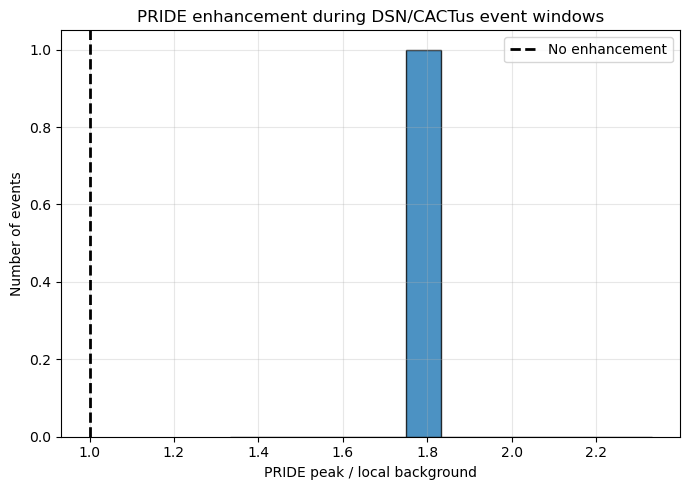

In [22]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.hist(
    covered["pride_peak_ratio"].dropna(),
    bins=12,
    edgecolor="black",
    alpha=0.8,
)

ax.axvline(
    1.0,
    linestyle="--",
    color="black",
    linewidth=2,
    label="No enhancement",
)

ax.set_xlabel("PRIDE peak / local background")
ax.set_ylabel("Number of events")

ax.set_title(
    "PRIDE enhancement during DSN/CACTus event windows"
)

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

# SECTION 4 — Event-Day Time-Series Diagnostics

In [23]:
detected_file = OUTPUT_DIR / f"phase_windows_detected_{YEAR}.csv"

clean_windows = pd.read_csv(detected_file)

clean_windows["mid"] = pd.to_datetime(
    clean_windows["mid"],
    utc=True,
)

clean_col_candidates = [
    "clean_signal",
    "clean_cir",
    "R_clean",
    "phase_ratio_clean",
    "phase_ratio_excess_clean",
    "amp_ratio_clean",
]

CLEAN_COL = None

for col in clean_col_candidates:
    if col in clean_windows.columns:
        CLEAN_COL = col
        break

print("Using cleaned column:", CLEAN_COL)

Using cleaned column: clean_signal


In [24]:
plot_bins = binned_df.copy().sort_index()
plot_bins.index = pd.to_datetime(plot_bins.index, utc=True)

clean_interp = (
    clean_windows[["mid", CLEAN_COL]]
    .dropna()
    .sort_values("mid")
)

plot_bins["clean_interp"] = np.interp(
    plot_bins.index.astype("int64"),
    clean_interp["mid"].astype("int64"),
    clean_interp[CLEAN_COL].to_numpy(float),
)

covered_days = (
    covered["event_day"]
    .dt.strftime("%Y-%m-%d")
    .tolist()
)

def plot_event_day(day_str):

    day = pd.to_datetime(day_str, utc=True).normalize()

    day_bins = plot_bins[
        plot_bins.index.normalize() == day
    ]

    day_events = events[
        events["mid"].dt.normalize() == day
    ]

    fig, axes = plt.subplots(
        3, 1,
        figsize=(12, 8),
        sharex=True,
        
    )

    ax1, ax2, ax3 = axes

    ax1.plot(
        day_bins.index,
        day_bins["dsn_sigma_phi_rad"],
        marker="o",
        label="DSN σφ",
    )

    ax1.set_ylabel("DSN σφ")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    ax2.plot(
        day_bins.index,
        day_bins["clean_interp"],
        marker="s",
        label="DSN cleaned",
    )

    ax2.set_ylabel("DSN cleaned")
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    ax3.plot(
        day_bins.index,
        day_bins["pride_scint_rad"],
        marker="^",
        linestyle="--",
        label="PRIDE",
    )

    ax3.set_ylabel("PRIDE")
    ax3.grid(True, alpha=0.3)
    ax3.legend()

    for ax in axes:
        for _, evt in day_events.iterrows():
            ax.axvspan(
                evt["start"],
                evt["end"],
                alpha=0.2,
            )

    ax3.set_xlabel("UTC time")

    plt.tight_layout()
    plt.show()

interact(
    plot_event_day,
    day_str=Dropdown(
        options=covered_days,
        description="Event day:",
    ),
);

interactive(children=(Dropdown(description='Event day:', options=('2014-05-21',), value='2014-05-21'), Output(…